In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
import sys
import seaborn
import pandas as pd
import itertools
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.metrics import r2_score
from multipledispatch import dispatch

seaborn.set_theme(style="whitegrid")

seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080']
# palette = itertools.cycle(seaborn.color_palette(palette=zesty))
palette = itertools.cycle(seaborn.color_palette('muted'))

src_dir = os.path.abspath("/home/mmfarrugia/repos/q2mm")
sys.path.append(src_dir)
#sys.path.append("/home/mfarrugi/repos/q2mm/rh-hybrid/schrodinger.ve/lib/python3.11/site-packages/q2mm-0.0.0-py3.11.egg")


from tools.ff_plotting import *

**Rhodium-catalyzed Hydrogenation of Enamides TSFF Parameterized via FUERZA Projections & Subsequent Gradient Optimization**

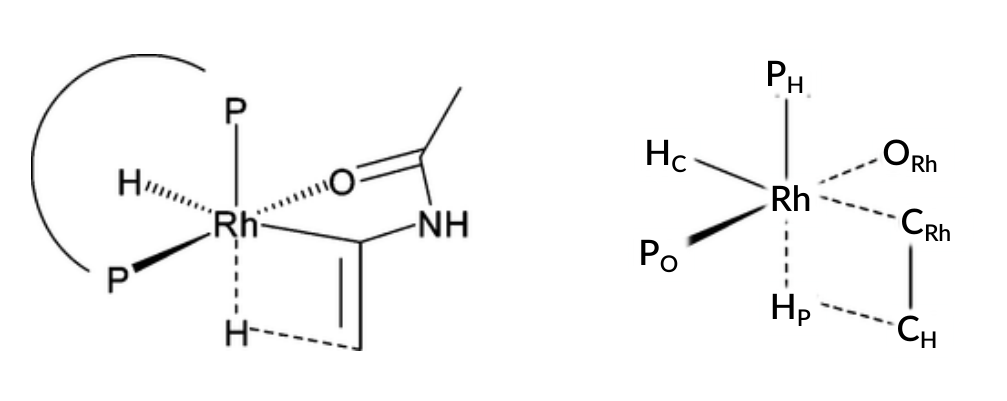

In [2]:
Image(filename='/home/mfarrugi/Documents/Rh_figures/rh_system_defn.png')

In [3]:
bond_cols = ["param_type", "atom1", "atom2", "Equilibrium Value", "Force Constant", "Dipole Moment", "FF"]
angle_cols = ["param_type", "atom1", "atom2", "atom3", "Equilibrium Value", "Force Constant", "FF"]
score_cols = ["Label", "Weight", "Reference", "Calculated", "Score", "FF"]
skiprows=[0, 1, 106390, 106391, 106392, 106393, 106394, 106395, 106396, 106397, 106398, 106399, 106400, 106401]
skip_hrows= [0, 114679, 114680, 114681, 114682, 114683, 114684]
bond_rows = np.arange(1859, 1867)
angle_rows = np.concatenate((np.arange(1867, 1889), [1908]))
bonds_rows = [str(bond_row+1) for bond_row in bond_rows]
angles_rows = [str(angle_row+1) for angle_row in angle_rows]
ff_rows = np.concatenate((bond_rows, angle_rows))
ffs_rows = [str(ff_row + 1) for ff_row in ff_rows]
rows = [*bond_rows, *angle_rows]
convergence_criteria = 0.001
num_params = 31
substructure_strings = ['HX-RH(-PX)-HX.C2*C2(.2)-N2-C2=O2.2', 'RH-PX']
param_names = ['Hc-Rh', 'Rh-P\u2095', 'Rh-P\u2092', 'Rh-H\u209A', 'Rh.CRh', 'Rh.ORh', 'H\u209A.C\u2095', 'C\u2095*CRh', 'Hc-Rh-P\u2095', 'Hc-Rh-P\u2092', 'Hc-Rh-H\u209A', 'Hc-Rh.CRh', 'Hc-Rh.ORh', 'P\u2095-Rh-H\u209A', 'P\u2092-Rh-H\u209A', 'P\u2095-Rh.CRh', 'P\u2092-Rh.CRh', 'P\u2095-Rh.ORh','P\u2092-Rh.ORh', 'H\u209A-Rh.CRh', 'H\u209A-Rh.ORh', 'CRh.Rh.ORh', 'Rh-H\u209A.C\u2095', 'H\u209A.C\u2095*00', 'CRh*C\u2095.H\u209A', 'Rh.CRh*C0', 'Rh.CRh*C2o', 'Rh.CRh*C\u2095', 'Rh.CRh-N2', 'Rh.ORh=C2', 'P\u209A-Rh-P\u2095']
bond_label_list = param_names[:8]
angle_label_list = param_names[8:]

base_direc = os.getcwd()

# Scores

## unoptimized data
static_score = 2.67645
static_scores = pd.read_csv('approximation/rh_approxn_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Approxn: '+str(static_score))
fuerza_score = 1.36077746
fuerza_scores = pd.read_csv('fuerza/rh_grad_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(fuerza_score))
gamma_fuerza_score = 0
gamma_fuerza_scores = pd.read_csv('gamma_q_fuerza/uninv.score.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=r'$\mathit{\gamma}$-FUERZA: '+str(gamma_fuerza_score))
ffuerza_score = 0
ffuerza_scores = pd.read_csv('qfuerza/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FFUERZA: '+str(ffuerza_score))
donoghue_score = 3.4895 # uninv eig
donoghue_eig_scores = pd.read_csv('donoghue/rh_don_eig_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_score)
uninv_fuerza_score = 1.2765 
uninv_fuerza_scores = pd.read_csv('uninv_q_fuerza/inv.score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=uninv_fuerza_score)
uninvh_fuerza_score = 0.0567
uninvh_fuerza_scores = pd.read_csv('uninv_q_fuerza/inv.score.h.txt', skiprows=skip_hrows, delim_whitespace=True, names=score_cols).assign(FF=uninvh_fuerza_score)

donoghue_inveig_score = 3.4895
donoghue_inveig_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/inv_eig/rh_don_inveig_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_inveig_score)
donoghue_invh_score = 0.3554
donoghue_invh_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/inv_h/rh_don_invh_start.txt', skiprows=skip_hrows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_invh_score)
#donoghue_h_score = 

## optimized data
normal_grad_score = 1.7479
normal_grad_scores = pd.read_csv('approximation/rh_static_grad_end.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Approxn-GRAD: '+str(normal_grad_score))
fuerza_grad_score = 0.8125
fuerza_grad_scores = pd.read_csv('fuerza/rh_grad_end.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA-GRAD: '+str(fuerza_grad_score))
gamma_fuerza_grad_score = 1.7482 #TODO
gamma_fuerza_grad_scores = pd.read_csv('gamma_q_fuerza/uninv.score.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=r'$\mathit{\gamma}$-FUERZA-GRAD: '+str(gamma_fuerza_grad_score))
ffuerza_grad_score = 1.7479001 #TODO
ffuerza_grad_scores = pd.read_csv('qfuerza/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FFUERZA-GRAD: '+str(ffuerza_grad_score))
donoghue_eig_grad_score = 0.8183
donoghue_eig_grad_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/uninv_eig/rh_don_grad_eig_end.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_eig_grad_score)
donoghue_inveig_grad_score = 0.8183
donoghue_inveig_grad_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/inv_eig/rh_don_grad_inveig_end.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_inveig_grad_score)
#donoghue_invh_grad_score =  0.0514 #scored with invh
#donoghue_invh_grad_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/inv_h/rh_don_grad_invh_end.txt', skiprows=skip_hrows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_invh_grad_score)
donoghue_invh_grad_score = 0.8308 #rescored with eig
donoghue_invh_grad_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/inv_h/rh_don_grad_invh_eig.compare.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_invh_grad_score)
#donoghue_h_grad_score = 0.0531 #scored with h
#donoghue_h_grad_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/h/rh_don_grad_h_end.txt', skiprows=skip_hrows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_h_grad_score)
donoghue_h_grad_score = 0.8360 #rescored with eig
donoghue_h_grad_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/rh_don_grad_h_eig.compare.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_h_grad_score)
#uninvfuerza_grad_score = 1.747901 #TODO
#uninvfuerza_grad_scores = pd.read_csv('uninv_q_fuerza/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA-GRAD: '+str(fuerza_grad_score))

# Bonds

## unoptimized
bond_normal = pd.read_csv('approximation/rh_static_start.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=static_score).assign(Parameter=bond_label_list) 
angle_normal = pd.read_csv('approximation/rh_static_start.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=static_score).assign(Parameter=angle_label_list)
bond_fuerza, angle_fuerza, param_fuerza = get_ff_params(base_direc, ['fuerza'], 'rh_hyd_enamide_q_seminario.fld', [fuerza_score], bond_rows, angle_rows, 'FUERZA')
bond_fuerza = bond_fuerza[0].assign(Parameter=bond_label_list) 
angle_fuerza = angle_fuerza[0].assign(Parameter=angle_label_list)
bond_gamma_fuerza, gamma_angle_fuerza, param_gamma_fuerza = get_ff_params(base_direc, ['gamma_q_fuerza'], 'gamma_q_fuerza.fld', [gamma_fuerza_score], bond_rows, angle_rows, r'$\mathit{\gamma}$-FUERZA')
gamma_angle_fuerza = gamma_angle_fuerza[0]
bond_ffuerza, angle_ffuerza, param_ffuerza = get_ff_params('qfuerza', [''], 'qfuerza_H.fld', [ffuerza_score], bond_rows, angle_rows, 'FFUERZA')
angle_ffuerza = angle_ffuerza[0]
bond_don = pd.read_csv('donoghue/donoghue_0mods.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=donoghue_score).assign(Parameter=bond_label_list) 
angle_don = pd.read_csv('donoghue/donoghue_0mods.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=donoghue_score).assign(Parameter=angle_label_list)
bond_don = bond_don.assign(ff_row=bonds_rows).assign(atom3='-')
angle_don = angle_don.assign(ff_row=angles_rows)
params_don = pd.concat([bond_don, angle_don])
melted_params_don = pd.melt(params_don, id_vars=['param_type', 'atom1', 'atom2', 'atom3', 'ff_row'], value_vars=['Force Constant'])

bond_uninvqf = pd.read_csv('uninv_q_fuerza/rh_uninv_start.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=static_score).assign(Parameter=bond_label_list) 
angle_uninvqf = pd.read_csv('uninv_q_fuerza/rh_uninv_start.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=static_score).assign(Parameter=angle_label_list)

## optimized
bond_normal_grad = pd.read_csv('approximation/rh_static_grad_end.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=normal_grad_score).assign(Parameter=bond_label_list) 
angle_normal_grad = pd.read_csv('approximation/rh_static_grad_end.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=normal_grad_score).assign(Parameter=angle_label_list)
bond_fuerza_grad = pd.read_csv('fuerza/rh_grad_end.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_grad_score).assign(Parameter=bond_label_list) 
angle_fuerza_grad = pd.read_csv('fuerza/rh_grad_end.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=fuerza_grad_score).assign(Parameter=angle_label_list)
gamma_bond_fuerza_grad = pd.read_csv('gamma_q_fuerza/gamma_q_fuerza.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=gamma_fuerza_score).assign(Parameter=bond_label_list) 
gamma_angle_fuerza_grad = pd.read_csv('gamma_q_fuerza/gamma_q_fuerza.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=gamma_fuerza_score).assign(Parameter=angle_label_list)
bond_ffuerza_grad = pd.read_csv('qfuerza/q_frankenfuerza_H.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=ffuerza_grad_score).assign(Parameter=bond_label_list) 
angle_ffuerza_grad = pd.read_csv('qfuerza/q_frankenfuerza_H.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=ffuerza_grad_score).assign(Parameter=angle_label_list)

bond_don_eig_grad = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/uninv_eig/rh_don_grad_eig_end.fld', skiprows=lambda x: x not in bond_rows, sep='\\s+', names=bond_cols).assign(FF=donoghue_eig_grad_score).assign(Parameter=bond_label_list) 
angle_don_eig_grad = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/uninv_eig/rh_don_grad_eig_end.fld', skiprows=lambda x: x not in angle_rows, sep='\\s+', names=angle_cols).assign(FF=donoghue_eig_grad_score).assign(Parameter=angle_label_list)
bond_don_inveig_grad = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/inv_eig/rh_don_grad_inveig_end.fld', skiprows=lambda x: x not in bond_rows, sep='\\s+', names=bond_cols).assign(FF=donoghue_inveig_grad_score).assign(Parameter=bond_label_list) 
angle_don_inveig_grad = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/inv_eig/rh_don_grad_inveig_end.fld', skiprows=lambda x: x not in angle_rows, sep='\\s+', names=angle_cols).assign(FF=donoghue_inveig_grad_score).assign(Parameter=angle_label_list)
bond_don_invh_grad = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/inv_h/rh_don_grad_invh_end.fld', skiprows=lambda x: x not in bond_rows, sep='\\s+', names=bond_cols).assign(FF=donoghue_invh_grad_score).assign(Parameter=bond_label_list) 
angle_don_invh_grad = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/inv_h/rh_don_grad_invh_end.fld', skiprows=lambda x: x not in angle_rows, sep='\\s+', names=angle_cols).assign(FF=donoghue_invh_grad_score).assign(Parameter=angle_label_list)
bond_don_h_grad = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/h/rh_don_grad_h_end.fld', skiprows=lambda x: x not in bond_rows, sep='\\s+', names=bond_cols).assign(FF=donoghue_h_grad_score).assign(Parameter=bond_label_list) 
angle_don_h_grad = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/h/rh_don_grad_h_end.fld', skiprows=lambda x: x not in angle_rows, sep='\\s+', names=angle_cols).assign(FF=donoghue_h_grad_score).assign(Parameter=angle_label_list)



donoghue_bonds = [bond_don, bond_don_eig_grad, bond_don_inveig_grad, bond_don_invh_grad, bond_don_h_grad]
donoghue_angles = [angle_don, angle_don_eig_grad, angle_don_inveig_grad, angle_don_invh_grad, angle_don_h_grad]
donoghue_scores = [donoghue_eig_scores, donoghue_eig_grad_scores, donoghue_inveig_grad_scores, donoghue_invh_grad_scores, donoghue_h_grad_scores]
donoghue_score_sums = ['DONOGHUE: '+'{0:.3f}'.format(donoghue_score),'DONOGHUE-EIG-GRAD: '+'{0:.3f}'.format(donoghue_eig_grad_score), 'DONOGHUE-INVEIG-GRAD: '+'{0:.3f}'.format(donoghue_inveig_grad_score), 'DONOGHUE-INVH-GRAD: '+'{0:.3f}'.format(donoghue_invh_grad_score), 'DONOGHUE-H-GRAD: '+'{0:.3f}'.format(donoghue_h_grad_score)]
#donoghue_score_sums = ['DONOGHUE: '+'{0:.3f}'.format(donoghue_score),'DONOGHUE-EIG-GRAD: '+'{0:.3f}'.format(donoghue_eig_grad_score), 'DONOGHUE-INVEIG-GRAD: '+'{0:.3f}'.format(donoghue_inveig_grad_score), 'DONOGHUE-INVH: '+'{0:.3f}'.format(donoghue_invh_score), 'DONOGHUE-INVH-GRAD: '+'{0:.3f}'.format(donoghue_invh_grad_score), 'DONOGHUE-H-GRAD: '+'{0:.3f}'.format(donoghue_h_grad_score)]

In [4]:
def style_per_plot_legends(axes:list):# -> list:
    for ax in axes:
        ax.legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=1., handletextpad=0.)
    return axes

@dispatch(list)
def style_fig_legend(axes:list):
    for ax in axes:
        ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)
    return axes

@dispatch(plt.Axes)
def style_fig_legend(axes:plt.Axes):
    ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)
    return ax

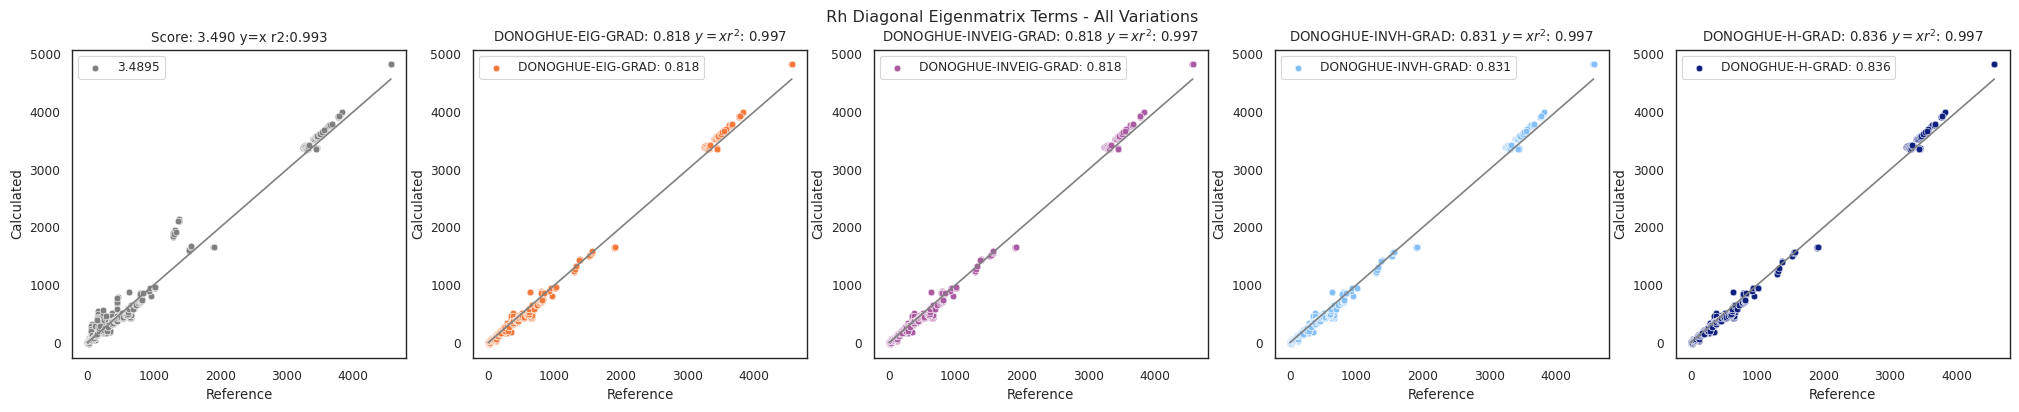

In [5]:
linear_fit_diag_scores(donoghue_eig_scores, donoghue_score, donoghue_scores[1:], donoghue_score_sums[1:], ' Rh Diagonal Eigenmatrix Terms - All Variations')

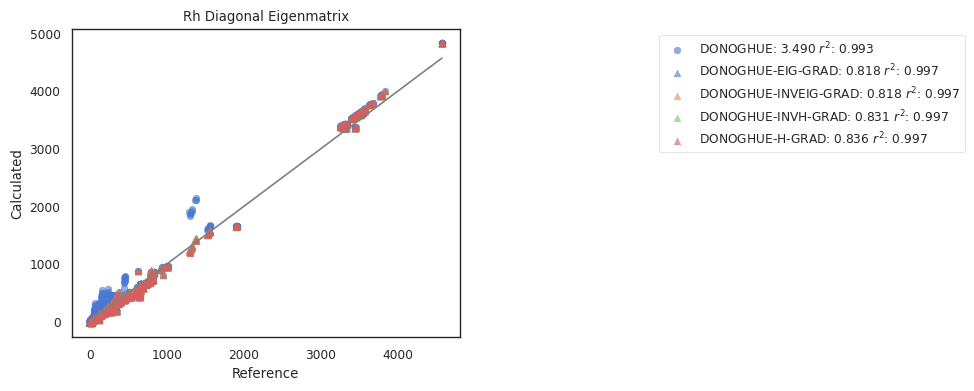

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5,4))
ax.set_title('Rh Diagonal Eigenmatrix')
# palette = itertools.cycle(seaborn.color_palette(palette=zesty))
# palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))
palette = itertools.cycle(seaborn.color_palette('muted'))
palette_opt = itertools.cycle(seaborn.color_palette('muted'))


for eigenmatrix, score in zip(donoghue_scores, donoghue_score_sums):
    diag = eigenmatrix.loc[eigenmatrix['Reference'] != 0.0000]
    diag = diag.loc[diag['Weight'] != 0.0000]
    #slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
    r2_ = r2_score(diag['Reference'], diag['Calculated'])
    if any(opt_flag in score for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
        marker="^"
        color = next(palette_opt)
        alpha=0.6
    elif any(opt_flag in score for opt_flag in ['uninvh', 'invh', 'UNINVH', 'INVH']):
        marker="x"
        color = next(palette)
        alpha=0.1
    else:
        marker = "o"
        color = next(palette)
        alpha=0.6
    seaborn.scatterplot(data=diag, y='Calculated', x='Reference', color=color, edgecolor=color, label=score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)), ax=ax, marker=marker, alpha = alpha)

seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax)
ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)

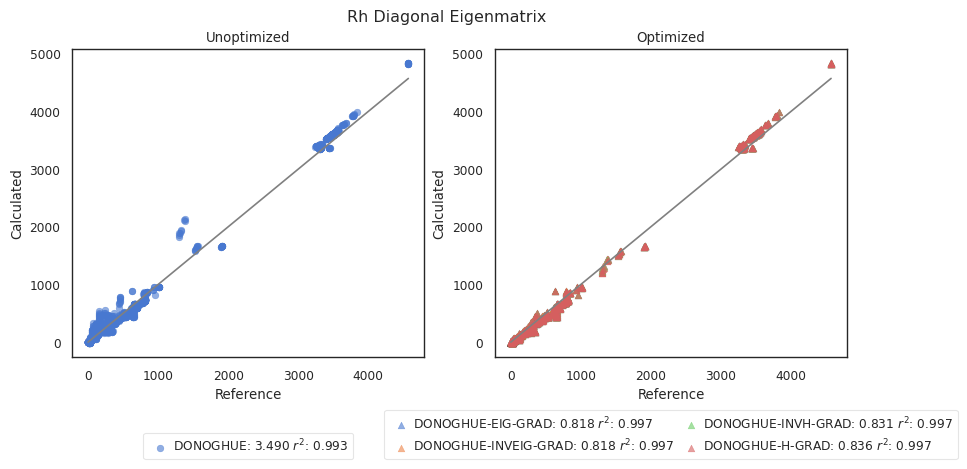

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Rh Diagonal Eigenmatrix')
# palette = itertools.cycle(seaborn.color_palette(palette=zesty))
# palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))
palette = itertools.cycle(seaborn.color_palette('muted'))
palette_opt = itertools.cycle(seaborn.color_palette('muted'))

r2_scores = []
r2_score_labels = []

for eigenmatrix, score in zip(donoghue_scores, donoghue_score_sums):
    diag = eigenmatrix.loc[eigenmatrix['Reference'] != 0.0000]
    diag = diag.loc[diag['Weight'] != 0.0000]
    #slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
    r2_ = r2_score(diag['Reference'], diag['Calculated'])
    r2_scores.append(r2_)
    if any(opt_flag in score for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
        marker="^"
        color = next(palette_opt)
        alpha=0.6
        axis=1
    elif any(opt_flag in score for opt_flag in ['uninh', 'invh', 'UNINVH', 'INVH']):
        marker="x"
        color = next(palette)
        alpha=0.1
        axis=0
    else:
        marker = "o"
        color = next(palette)
        alpha=0.6
        axis=0
    seaborn.scatterplot(data=diag, y='Calculated', x='Reference', color=color, edgecolor=color, label=score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)), ax=ax[axis], marker=marker, alpha = alpha)
    r2_score_labels.append(score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)))

seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[0])
seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[1])
ax[0].set_title('Unoptimized')
ax[1].set_title('Optimized')
ax[0].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)
ax[1].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)

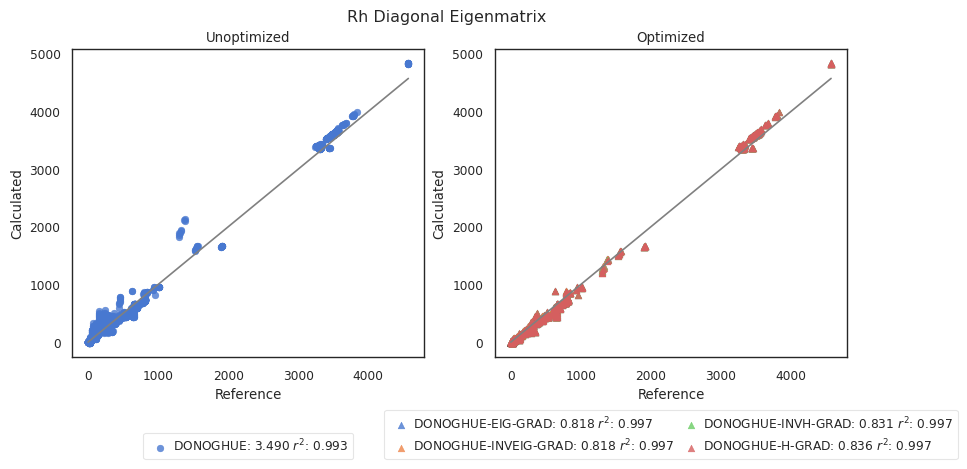

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Rh Diagonal Eigenmatrix')
# palette = itertools.cycle(seaborn.color_palette(palette=zesty))
# palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))
palette = itertools.cycle(seaborn.color_palette('muted'))
palette_opt = itertools.cycle(seaborn.color_palette('muted'))

r2_scores = []
r2_score_labels = []

for eigenmatrix, score in zip(donoghue_scores, donoghue_score_sums):
    diag = eigenmatrix.loc[eigenmatrix['Reference'] != 0.0000]
    diag = diag.loc[diag['Weight'] != 0.0000]
    #slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
    r2_ = r2_score(diag['Reference'], diag['Calculated'])
    r2_scores.append(r2_)
    if any(opt_flag in score for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
        marker="^"
        color = next(palette_opt)
        axis=1
    else:
        marker = "o"
        color = next(palette)
        axis=0
    seaborn.scatterplot(data=diag, y='Calculated', x='Reference', color=color, edgecolor=color, label=score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)), ax=ax[axis], marker=marker, alpha = 0.8)
    r2_score_labels.append(score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)))

seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[0])
seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[1])
ax[0].set_title('Unoptimized')
ax[1].set_title('Optimized')
ax[0].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)
ax[1].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)

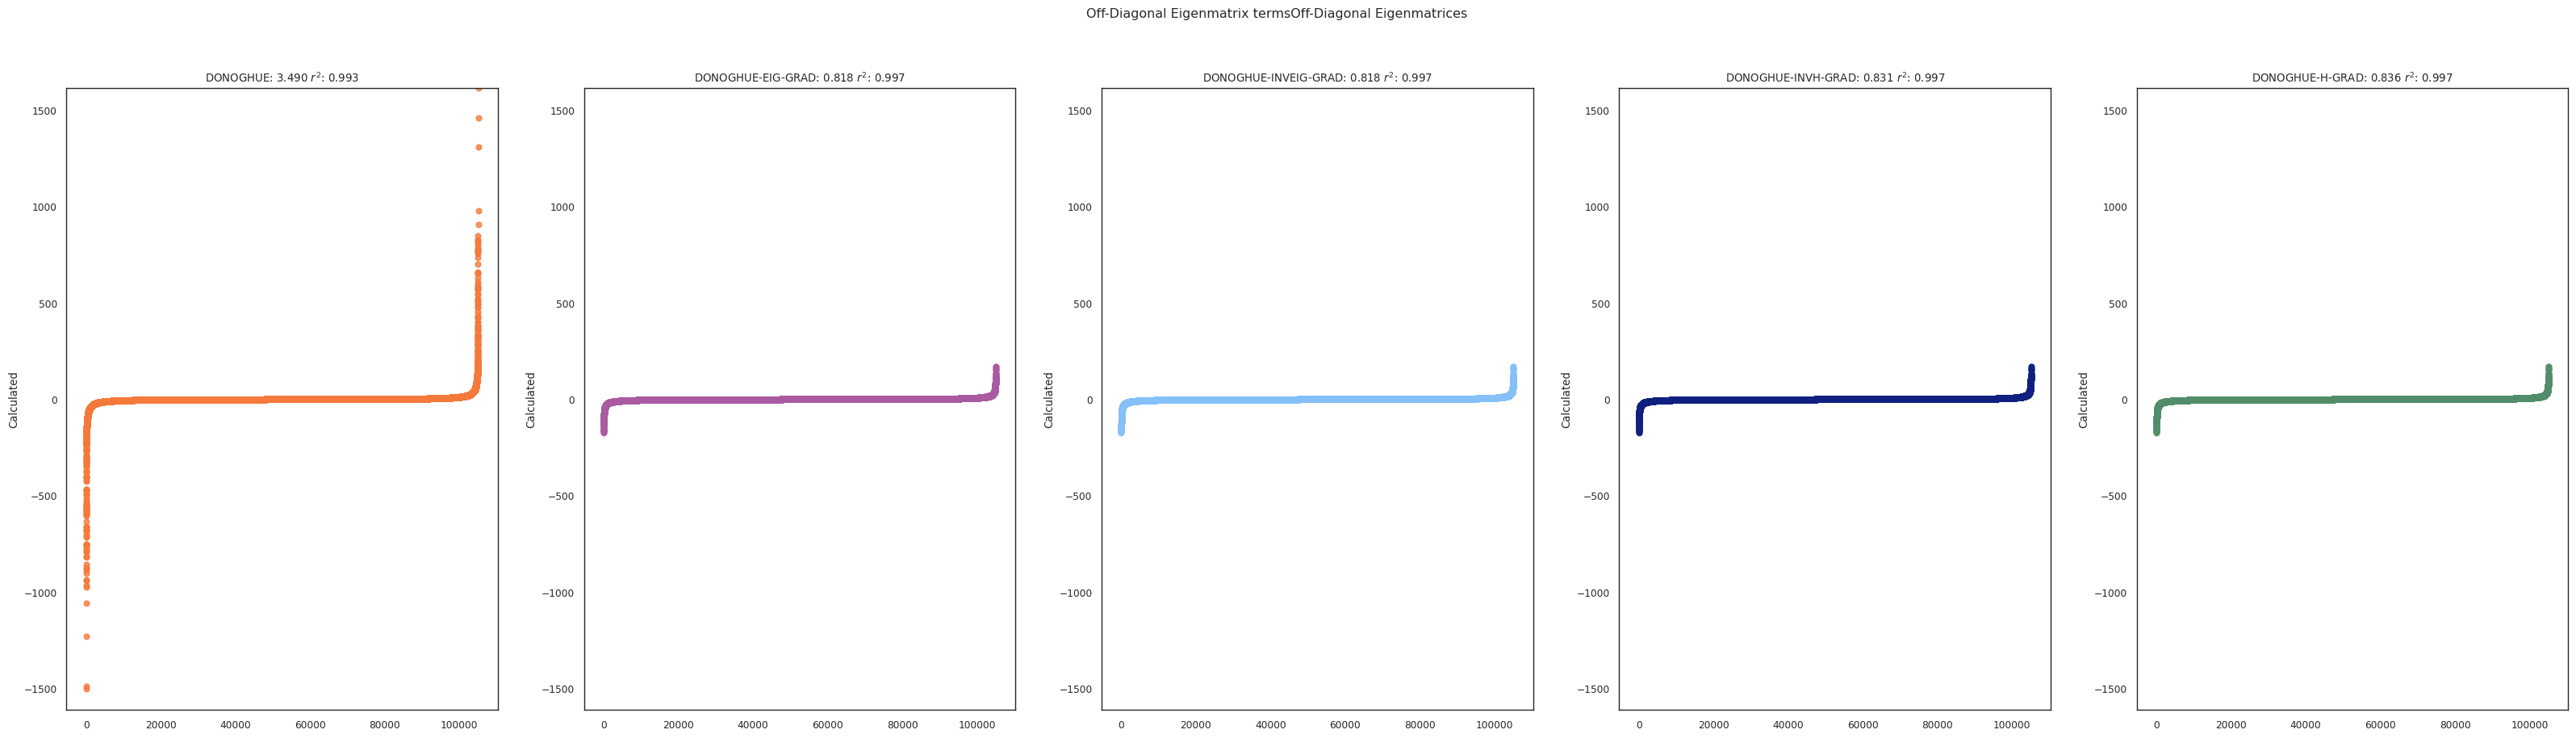

In [9]:
plot_off_diag_scatter(donoghue_scores, r2_score_labels, 'Off-Diagonal Eigenmatrices')

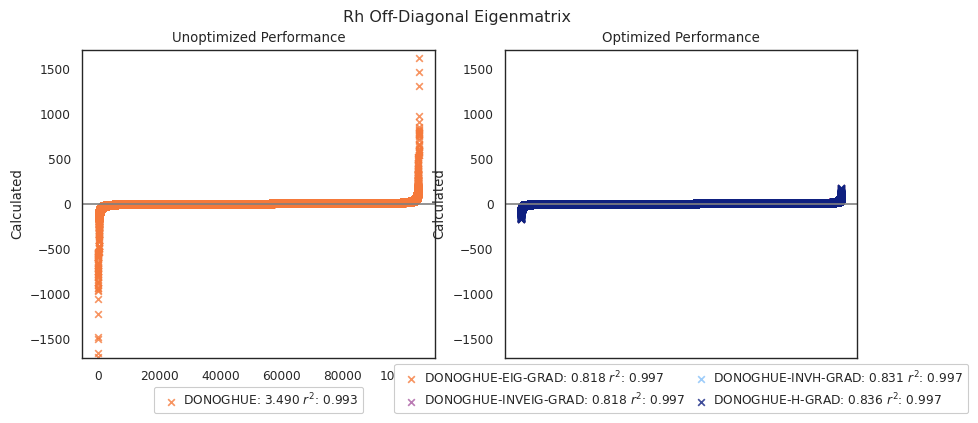

In [10]:
def off_diag_scatter(score_matrices:list, total_scores:list, title:str=''):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle('Rh Off-Diagonal Eigenmatrix'+title)
    palette = itertools.cycle(zesty_palette)
    palette_opt = itertools.cycle(zesty_palette)
    max_y = 0.

    for i, run in enumerate(score_matrices):
        off_diag = run.loc[run['Reference'] == 0.0000]
        off_diag = off_diag.loc[off_diag['Weight'] != 0.0000]
        off_diag = off_diag.sort_values(by='Calculated', ignore_index=True)

        if any(opt_flag in total_scores[i] for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
            color = next(palette_opt)
            axis=1
        else:
            color = next(palette)
            axis=0
        
        seaborn.regplot(data=off_diag, x=off_diag.index, label=r2_score_labels[i], y='Calculated', marker='x', fit_reg=False, ax=ax[axis], color=color)
        max_y = max(max_y, max(off_diag['Calculated']))

    max_y = max_y + 100
    ax[0].set_ylim(top=max_y, bottom=-max_y)
    ax[1].set_ylim(top=max_y, bottom=-max_y)
    ax[0].set_title('Unoptimized Performance')
    ax[1].set_title('Optimized Performance')
    ax[0].legend(bbox_to_anchor=(0.5, -0.2), loc='lower center', fancybox=True, framealpha=1, ncol=2, columnspacing=0.3, handletextpad=0.)
    ax[1].legend(bbox_to_anchor=(0.5, -0.2), loc='lower center', fancybox=True, framealpha=1, ncol=2, columnspacing=0.3, handletextpad=0.)
    ax[0].axhline(y=0, color='gray')
    ax[1].axhline(y=0, color='gray')
    plt.show()

off_diag_scatter(donoghue_scores, donoghue_score_sums)

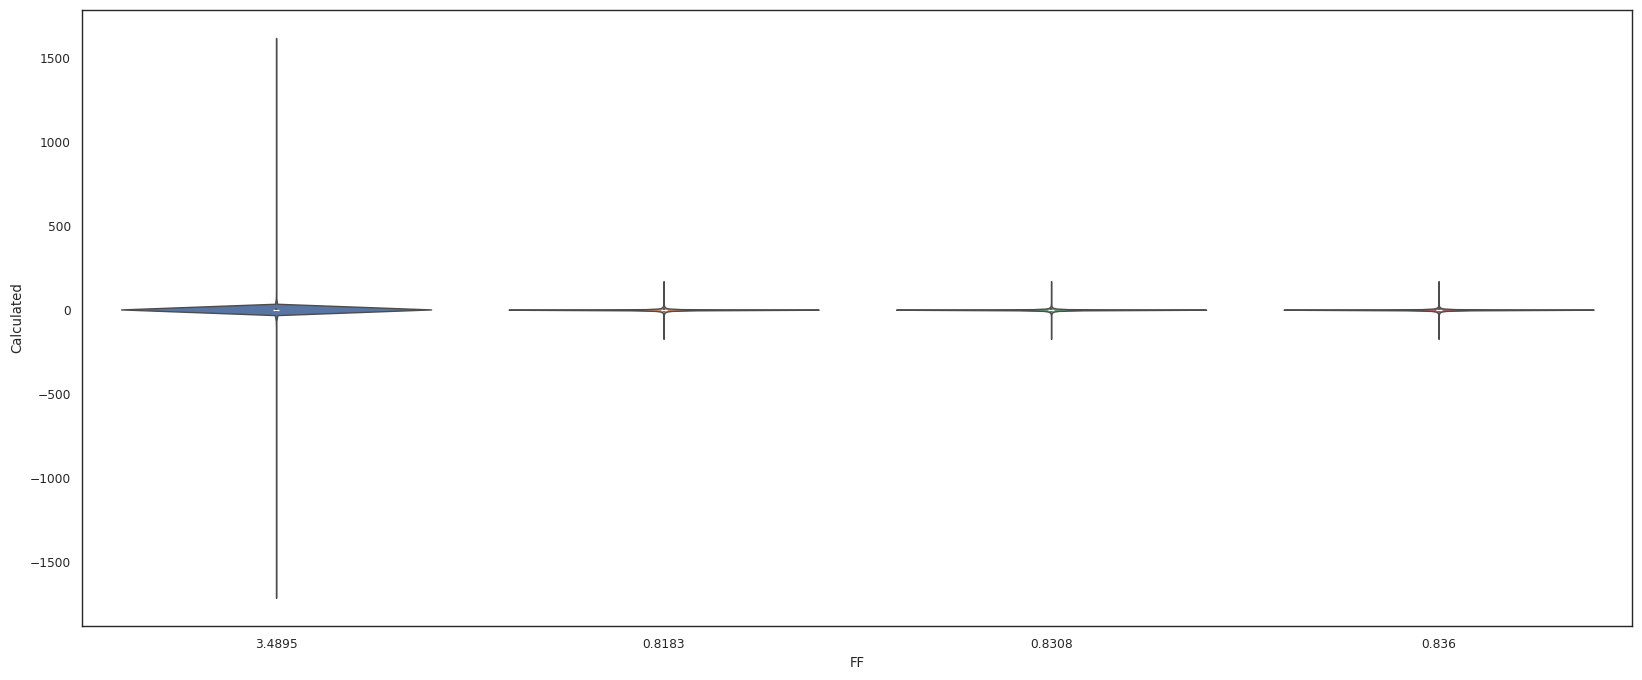

In [11]:
plot_off_diag_violin(donoghue_eig_scores, donoghue_score, donoghue_scores[1:], donoghue_score_sums[1:])

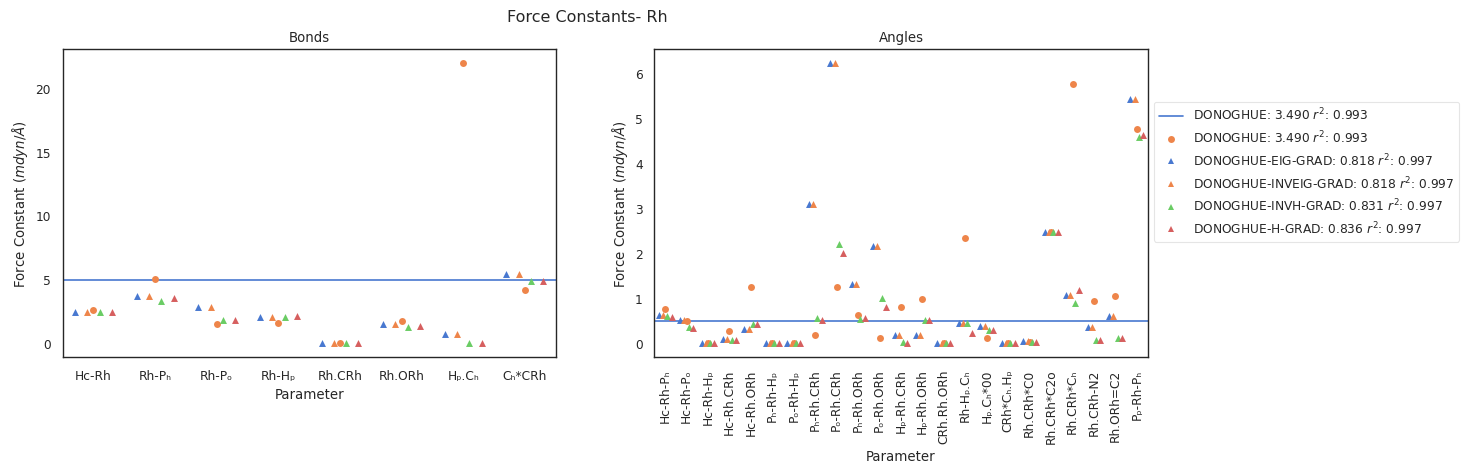

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Bonds'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
        <Axes: title={'center': 'Angles'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>],
       dtype=object))

In [12]:
plot_ff_params_v_static(donoghue_bonds, donoghue_angles, r2_score_labels, bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=r2_score_labels[0], title='- Rh')

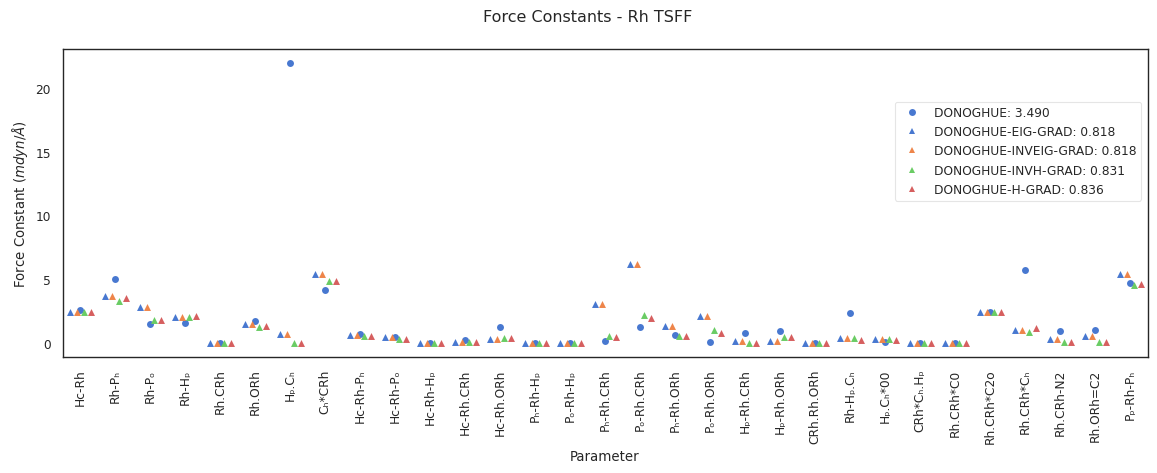

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Force Constants'+' - Rh TSFF')

colors_pick = seaborn.color_palette('muted')
#colors_pick - seaborn.color_palette(palette=zesty)

param_unopt, param_opt = filter_params_by_opt(donoghue_bonds, donoghue_angles, donoghue_score_sums)

seaborn.stripplot(data=param_unopt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick)) # type: ignore
seaborn.stripplot(data=param_opt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick), marker='^') # type: ignore

plt.xticks(rotation=90)
ax.legend(bbox_to_anchor=(1.0, 0.85), fancybox=True, framealpha=0.5)
ax.set_ylabel(r'Force Constant ($mdyn/\AA$)')
plt.show()

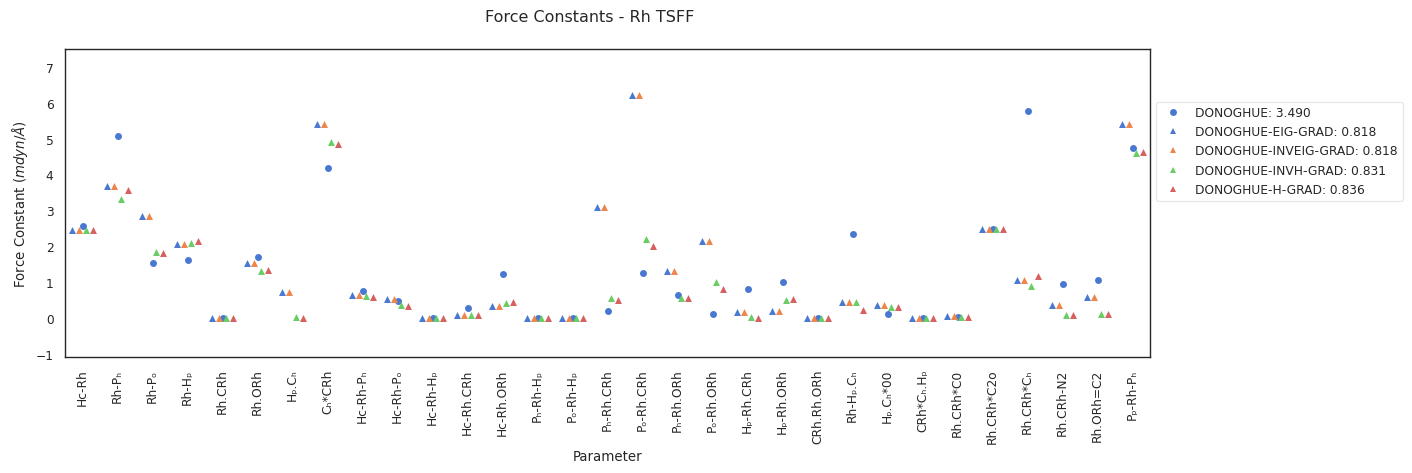

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Force Constants'+' - Rh TSFF')

colors_pick = seaborn.color_palette('muted')
#colors_pick - seaborn.color_palette(palette=zesty)

param_unopt, param_opt = filter_params_by_opt(donoghue_bonds, donoghue_angles, donoghue_score_sums)

seaborn.stripplot(data=param_unopt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick)) # type: ignore
seaborn.stripplot(data=param_opt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick), marker='^') # type: ignore

plt.xticks(rotation=90)
plt.ylim(top=7.5)
ax.legend(bbox_to_anchor=(1.0, 0.85), fancybox=True, framealpha=0.5)
ax.set_ylabel(r'Force Constant ($mdyn/\AA$)')
plt.show()

ADD IN DONOGHUE WITH SOFT RXN FC TO COMPARE

In [15]:
donoghue_soft_score = 0.9972 # scored with eig
donoghue_soft_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/rh_don_soft_eig_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_soft_score)
bond_don_soft = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/donoghue_soft_0mods.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=donoghue_soft_score).assign(Parameter=bond_label_list) 
angle_don_soft = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/donoghue_soft_0mods.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=donoghue_soft_score).assign(Parameter=angle_label_list)
donoghue_scores.append(donoghue_soft_scores)
donoghue_score_sums.append('DON-SOFT-EIG: '+'{0:.3f}'.format(donoghue_soft_score))
donoghue_bonds.append(bond_don_soft)
donoghue_angles.append(angle_don_soft)
#donoghue_soft_grad_score = 0 # optimized and scored with eig
#donoghue_soft_grad_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/rh_don_soft_eig_end.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_soft_grad_score)
#bond_don_soft_grad = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/rh_don_soft_eig_end.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=donoghue_score).assign(Parameter=bond_label_list) 
#angle_don_soft_grad = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/rh_don_soft_eig_end.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=donoghue_score).assign(Parameter=angle_label_list)
#donoghue_scores.append(donoghue_soft_grad_scores)
#donoghue_score_sums.append('DON-SOFT-EIG-GRAD: '+'{0:.3f}'.format(donoghue_soft_grad_score))
# donoghue_bonds.append(bond_don_soft_grad)
# donoghue_angles.append(angle_don_soft_grad)

In [16]:
r2_scores, r2_score_labels = score_r2s(donoghue_scores, donoghue_score_sums)

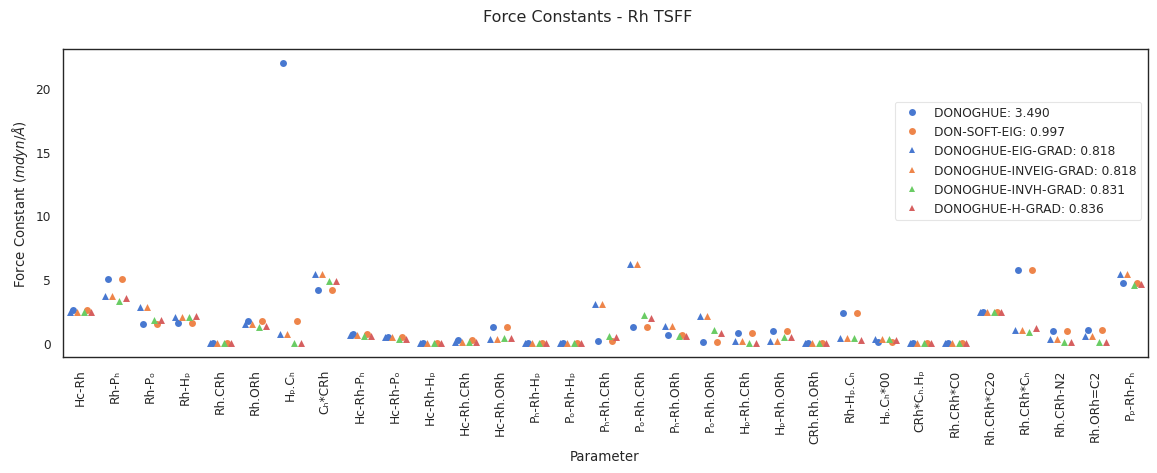

In [17]:
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Force Constants'+' - Rh TSFF')

colors_pick = seaborn.color_palette('muted')
#colors_pick - seaborn.color_palette(palette=zesty)

param_unopt, param_opt = filter_params_by_opt(donoghue_bonds, donoghue_angles, donoghue_score_sums)

seaborn.stripplot(data=param_unopt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick)) # type: ignore
seaborn.stripplot(data=param_opt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick), marker='^') # type: ignore

plt.xticks(rotation=90)
ax.legend(bbox_to_anchor=(1.0, 0.85), fancybox=True, framealpha=0.5)
ax.set_ylabel(r'Force Constant ($mdyn/\AA$)')
plt.show()

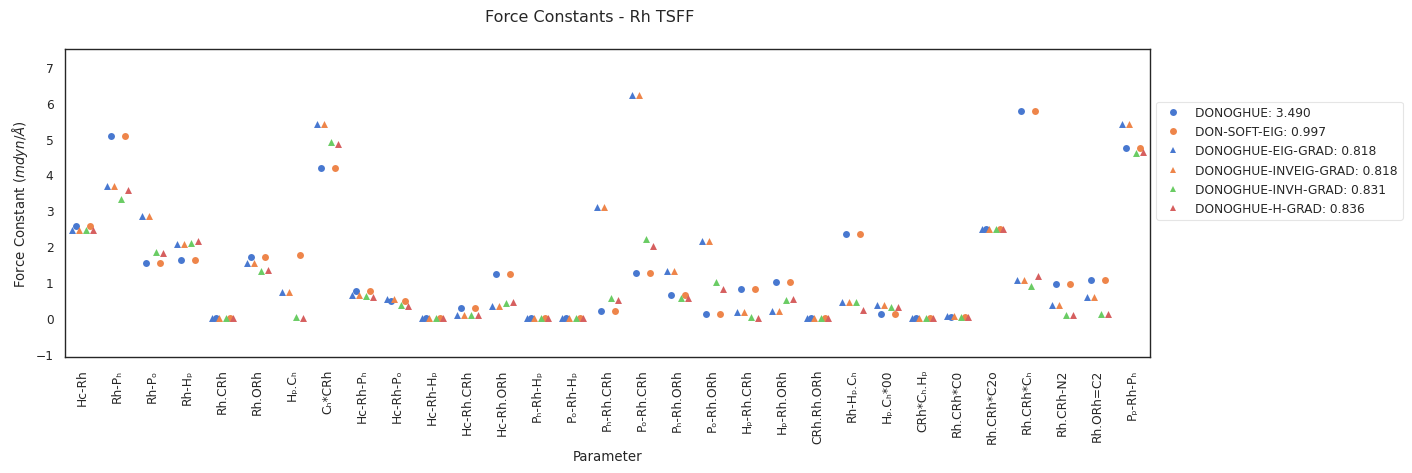

In [18]:
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Force Constants'+' - Rh TSFF')

colors_pick = seaborn.color_palette('muted')
#colors_pick - seaborn.color_palette(palette=zesty)

param_unopt, param_opt = filter_params_by_opt(donoghue_bonds, donoghue_angles, donoghue_score_sums)

seaborn.stripplot(data=param_unopt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick)) # type: ignore
seaborn.stripplot(data=param_opt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick), marker='^') # type: ignore

plt.xticks(rotation=90)
plt.ylim(top=7.5)
ax.legend(bbox_to_anchor=(1.0, 0.85), fancybox=True, framealpha=0.5)
ax.set_ylabel(r'Force Constant ($mdyn/\AA$)')
plt.show()

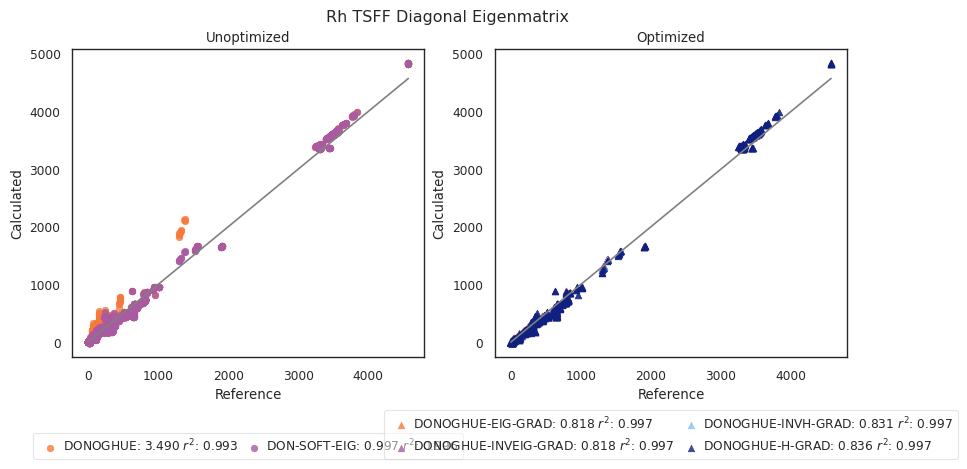

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Rh TSFF Diagonal Eigenmatrix')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))
palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))

r2_scores = []
r2_score_labels = []

for eigenmatrix, score in zip(donoghue_scores, donoghue_score_sums):
    diag = eigenmatrix.loc[eigenmatrix['Reference'] != 0.0000]
    diag = diag.loc[diag['Weight'] != 0.0000]
    #slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
    r2_ = r2_score(diag['Reference'], diag['Calculated'])
    r2_scores.append(r2_)
    if any(opt_flag in score for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
        marker="^"
        color = next(palette_opt)
        axis=1
    else:
        marker = "o"
        color = next(palette)
        axis=0
    seaborn.scatterplot(data=diag, y='Calculated', x='Reference', color=color, edgecolor=color, label=score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)), ax=ax[axis], marker=marker, alpha = 0.8)
    r2_score_labels.append(score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)))

seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[0])
seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[1])
ax[0].set_title('Unoptimized')
ax[1].set_title('Optimized')
ax[0].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)
ax[1].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)

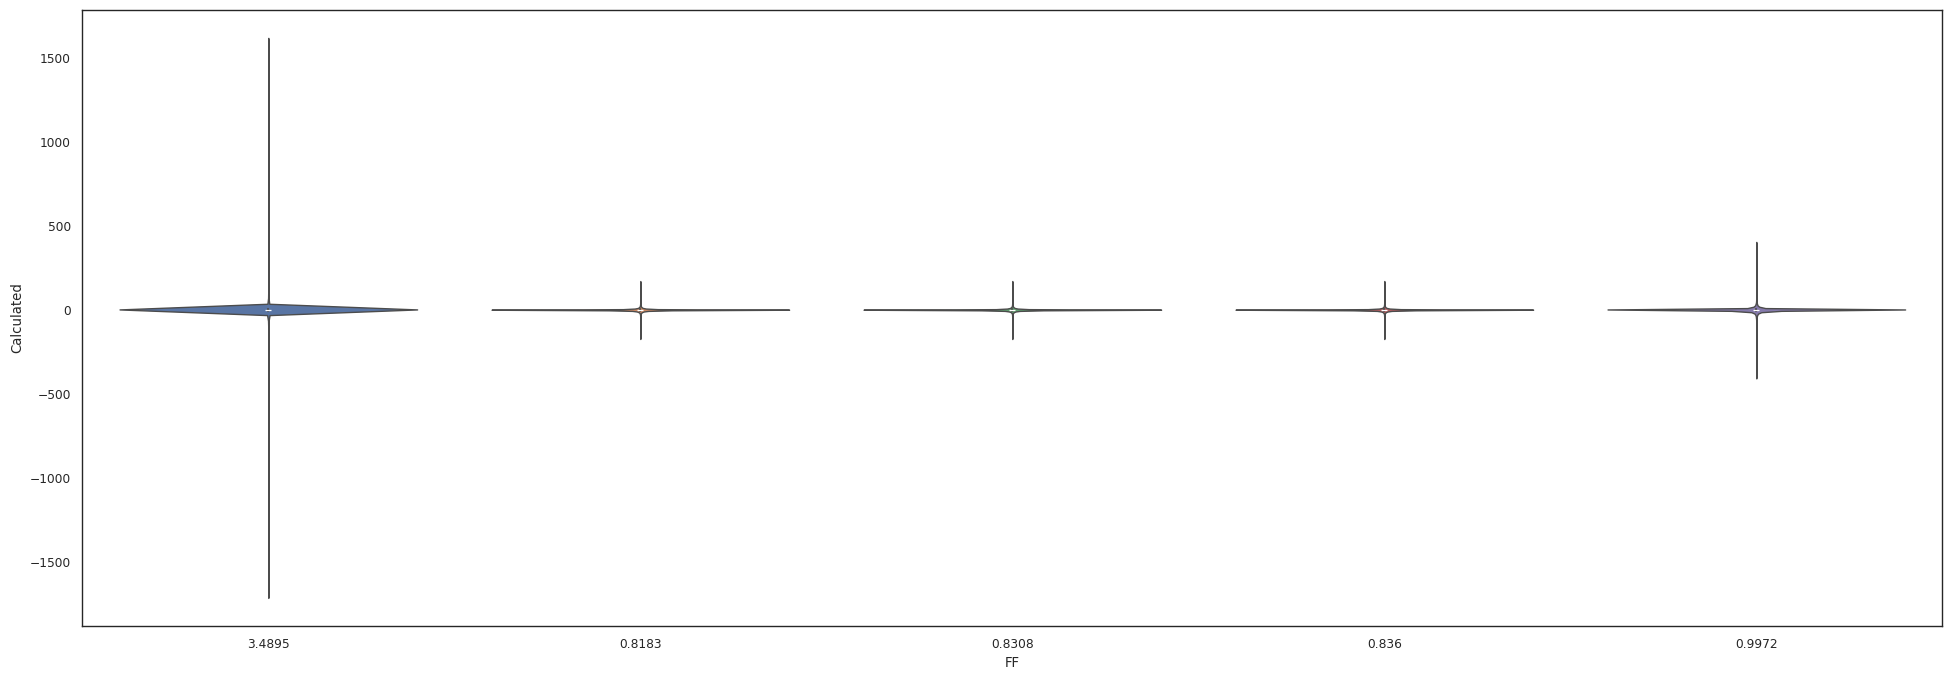

In [20]:
plot_off_diag_violin(donoghue_eig_scores, r2_score_labels[0], donoghue_scores[1:], r2_score_labels[1:])

In [21]:
donoghue_invh_grad_score = 0.8308 #rescored with eig
donoghue_invh_grad_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/inv_h/rh_don_grad_invh_eig.compare.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_invh_grad_score)
donoghue_scores.append(donoghue_invh_grad_scores)
donoghue_score_sums.append('DON-INVH-GRAD-EIG: 0.831')
# donoghue_soft_invh_score = 0
# donoghue_soft_invh_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/rh_don_soft_invh.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_soft_score)
# donoghue_scores.append(donoghue_soft_invh_scores)
# donoghue_score_sums.append('DON-SOFT-INVH: ')

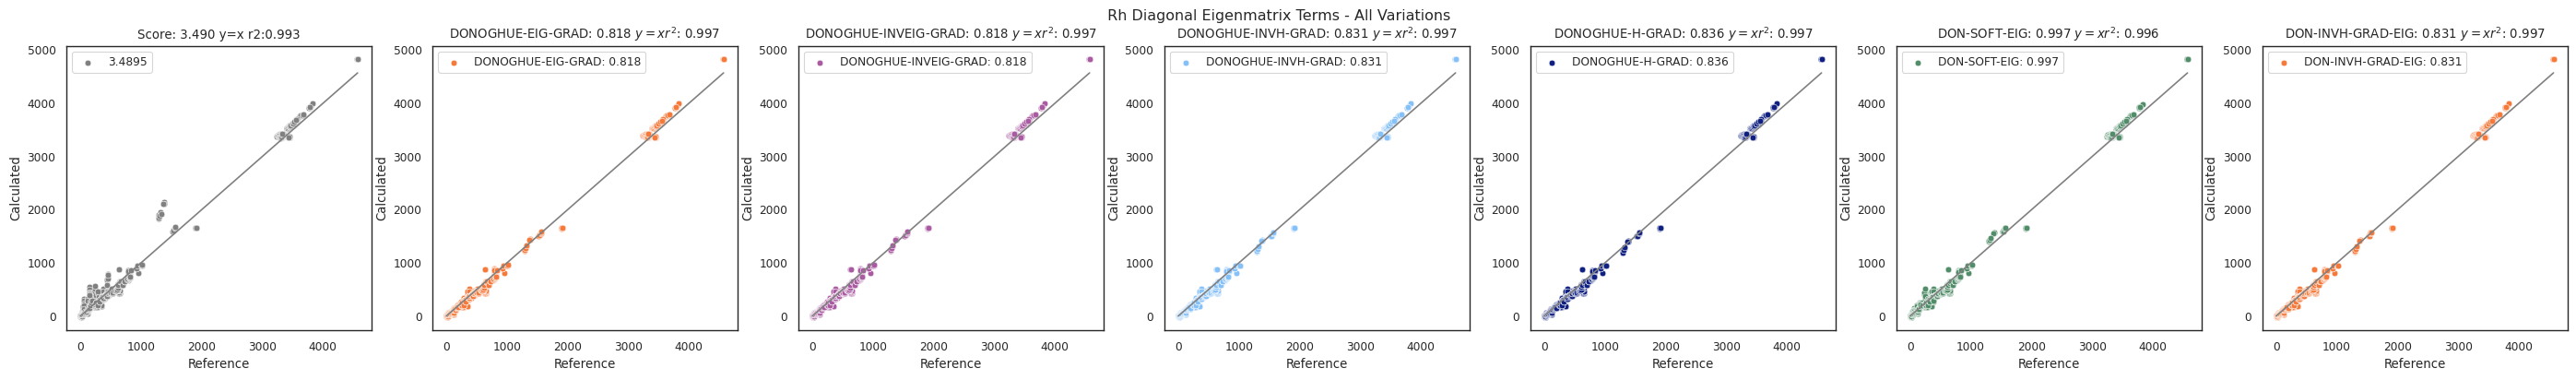

In [22]:
linear_fit_diag_scores(donoghue_eig_scores, donoghue_score, donoghue_scores[1:], donoghue_score_sums[1:], ' Rh Diagonal Eigenmatrix Terms - All Variations')

In [23]:
# import inveig_invh